#  Introduction & Setup

## Necessary packages

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, make_scorer
from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor, plot_importance
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.mixture import GaussianMixture

import matplotlib.pyplot as plt
import seaborn as sns

## Customized functions

In [ ]:
def load_train_data(file):
  '''
  Load train data and define target variable
  '''
  col_names = (['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
          [f'sensor_{i+1}' for i in range(21)])
  df = pd.read_csv(file, sep=r'\s+', header=None, names=col_names)
  # Define target variable
  max_cycle = df.groupby('unit')['cycle'].max()
  df['max_cycle'] = df['unit'].map(max_cycle) # mapping unit to max_cycle
  df['RUL'] = df['max_cycle'] - df['cycle']
  df['RUL_piecewise'] = df['RUL'].clip(upper=125)
  df.drop('max_cycle', axis=1, inplace=True)
  return df

In [ ]:
def load_test_data(file, rul):
  '''
  Load test data and define target variable
  '''
  col_names = (['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
          [f'sensor_{i+1}' for i in range(21)])

  df = pd.read_csv(file, sep=r'\s+', header=None, names=col_names)
  rul_df = pd.read_csv(rul, header=None, names=['RUL'])
  rul_df.index += 1

  df['max_cycle'] = df['unit'].map(df.groupby('unit')['cycle'].max())
  # The True RUL at any given cycle = (Max Cycle - Current Cycle) + Final Ground Truth RUL
  df['True_RUL'] = (df['max_cycle'] - df['cycle']) + df['unit'].map(rul_df['RUL'])
  df['True_RUL_piecewise'] = df['True_RUL'].clip(upper=125)
  df.drop('max_cycle', axis=1, inplace=True)

  return df

In [ ]:
def normalize_train_data(df, sensors, kmeans):
  '''
  Normalize train data by regime (flight regime)
  '''
  df['flight_regime'] = kmeans.fit_predict(df[['op_setting_1', 'op_setting_2', 'op_setting_3']])

  normalized_cols = [f'{sensor}_norm' for sensor in sensors]
  # Initialize empty columns for the normalized data
  for col in normalized_cols:
    df[col] = 0.0

  # Dictionary to save all scalers
  regime_scalers = {}

  # Loop through each of the 6 flight regimes
  for regime in df['flight_regime'].unique():
    scaler = StandardScaler()

    # 1. Isolate the training data for a regime
    regime_mask = df['flight_regime'] == regime

    # 2. Fit and transform only on the training data
    df.loc[regime_mask, normalized_cols] = scaler.fit_transform(df.loc[regime_mask, sensors])

    # 3. Save the fitted scaler into our dictionary
    regime_scalers[regime] = scaler

  return normalized_cols, regime_scalers

In [ ]:
def normalize_test_data(df, sensors, kmeans, regime_scalers):
  '''
  Normalize test data by regime found in train data
  '''
  df['flight_regime'] = kmeans.predict(df[['op_setting_1', 'op_setting_2', 'op_setting_3']])

  normalized_cols = [f'{sensor}_norm' for sensor in sensors]
  # Initialize empty columns for the normalized data
  for col in normalized_cols:
    df[col] = 0.0

  # Loop through the test regimes
  for regime in df['flight_regime'].unique():
    # 1. Isolate test data for THIS regime
    regime_mask = df['flight_regime'] == regime

    # 2. Load the corresponding fitted scaler from training
    if regime in regime_scalers:
      scaler = regime_scalers[regime]

      # 3. Strictly transform() without fit()
      df.loc[regime_mask, normalized_cols] = scaler.transform(df.loc[regime_mask, sensors])
    else:
      # Fallback just in case test set has a totally unseen regime
      df.loc[regime_mask, normalized_cols] = df.loc[regime_mask, sensors].values

  return normalized_cols

In [ ]:
def smooth_data(df, columns, window_size=15, smoothing='ewma'):
  '''
  Smooth data using EWMA or SMA
  '''
  smoothed_features = []

  for col in columns:
    mean_col_name = f'{col}_{smoothing}_mean'
    std_col_name = f'{col}_{smoothing}_std'

    if smoothing == 'sma':
      df[mean_col_name] = df.groupby('unit')[col].transform(lambda x: x.rolling(window_size, 1).mean())
      df[std_col_name] = df.groupby('unit')[col].transform(lambda x: x.rolling(window_size, 1).std().fillna(0))
    elif smoothing == 'ewma':
      # EWMA Mean (Penalizing lag)
      df[mean_col_name] = df.groupby('unit')[col].transform(
          lambda x: x.ewm(span=window_size, adjust=False).mean()
        )
      # EWMA Volatility (Capturing engine vibration)
      df[std_col_name] = df.groupby('unit')[col].transform(
          lambda x: x.ewm(span=window_size, adjust=False).std().fillna(0)
        )

    smoothed_features.extend([mean_col_name, std_col_name])
  return smoothed_features

In [ ]:
def asymmetric_score(y_true, y_pred):
  """
  Official asymmetric scoring function for NASA CMAPSS. Penalizes late predictions more heavily.
  """
  errors = y_pred - y_true
  score = 0
  for e in errors:
    if e < 0:
      score += np.exp(-e / 13.0) - 1
    else:
      score += np.exp(e / 10.0) - 1
  return score/len(y_true)

# Covariate Drift on Naive Model

## Load Train_FD001

In [ ]:
train_1 = load_train_data('train_FD001.txt')

## Feature Selection

In [ ]:
# Invariant variables
constant_variables = []
for col in train_1.columns:
  if train_1[col].nunique() < 2 and col.startswith('sensor_'):
    constant_variables.append(col)

In [ ]:
train_1.drop(constant_variables, axis=1, inplace=True)

## Feature Engineering

In [ ]:
features_1 = [col for col in train_1.columns if col.startswith('sensor_')]

In [ ]:
# Simple Moving Average (SMA) features
smoothed_features_1 = smooth_data(train_1, features_1, window_size=15, smoothing='sma')

## Train Model on train_FD001

In [ ]:
# Train the Naive Model
X_train_naive = train_1[features_1 + smoothed_features_1]
y_train_naive = train_1['RUL_piecewise']

In [ ]:
model_naive = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model_naive.fit(X_train_naive, y_train_naive)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

## Cross-Validation on train_FD001

In [ ]:
gkf = GroupKFold(n_splits=5)
rf_cv_rmses =[]
asy_scores = []

for train_idx, val_idx in gkf.split(X_train_naive, y_train_naive, groups=train_1['unit']):
  X_train, X_val = X_train_naive.iloc[train_idx], X_train_naive.iloc[val_idx]
  y_train, y_val = y_train_naive.iloc[train_idx], y_train_naive.iloc[val_idx]

  # Initialize Random Forest (max_depth limits overfitting)
  rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
  rf_model.fit(X_train, y_train)

  # Predict and calculate RMSE
  preds = rf_model.predict(X_val)
  rmse = root_mean_squared_error(y_val, preds)
  rf_cv_rmses.append(rmse)
  asy_scores.append(asymmetric_score(y_val, preds))

avg_rmse = np.mean(rf_cv_rmses)
avg_asy = np.mean(asy_scores)
print(f"Average CV RMSE: {avg_rmse:.2f}")
print(f"Average NASA Asymmetric Score: {avg_asy:.2f}")

Average CV RMSE: 18.86
Average NASA Asymmetric Score: 15.33


## Evaluate model on test_FD001

In [ ]:
test_1 = load_test_data('test_FD001.txt', 'RUL_FD001.txt')

In [ ]:
smoothed_features_1 = smooth_data(test_1, features_1, window_size=15, smoothing='sma')

In [ ]:
X_test = test_1.groupby('unit').tail(15)[features_1 + smoothed_features_1]
predictions = model_naive.predict(X_test)
y_test = test_1.groupby('unit').tail(15)['True_RUL_piecewise']
test_rmse = root_mean_squared_error(y_test, predictions)
test_asy = asymmetric_score(y_test, predictions)
print(f"M1 Test Baseline RMSE (On complex FD002 data): {test_rmse:.2f}")
print(f"M1 Test Baseline Asymmetric Score: {test_asy:.2f}")

M1 Test Baseline RMSE (On complex FD002 data): 20.85
M1 Test Baseline Asymmetric Score: 53.02


## Evaluate model on test_FD002

In [ ]:
test_2 = load_test_data('test_FD002.txt', 'RUL_FD002.txt')

In [ ]:
test_2.shape

(33991, 28)

In [ ]:
features_2 = features_1 # Use the same sensor list
smoothed_features_2 = smooth_data(test_2, features_2, window_size=15, smoothing='sma')

In [ ]:
X_test_drift = test_2.groupby('unit').tail(15)[features_2 + smoothed_features_2]
y_true_drift = test_2.groupby('unit').tail(15)['True_RUL_piecewise']

In [ ]:
drift_predictions = model_naive.predict(X_test_drift)

In [ ]:
drift_rmse = root_mean_squared_error(y_true_drift, drift_predictions)
drift_asy = asymmetric_score(y_true_drift, drift_predictions)

In [ ]:
print(f"Drift Scenario RMSE (On complex FD002 data): {drift_rmse:.2f}")
print(f"Drift Scenario Asymmetric Score: {drift_asy:.2f}")

Drift Scenario RMSE (On complex FD002 data): 40.47
Drift Scenario Asymmetric Score: 124.85


## Model Perfornamce Degradation

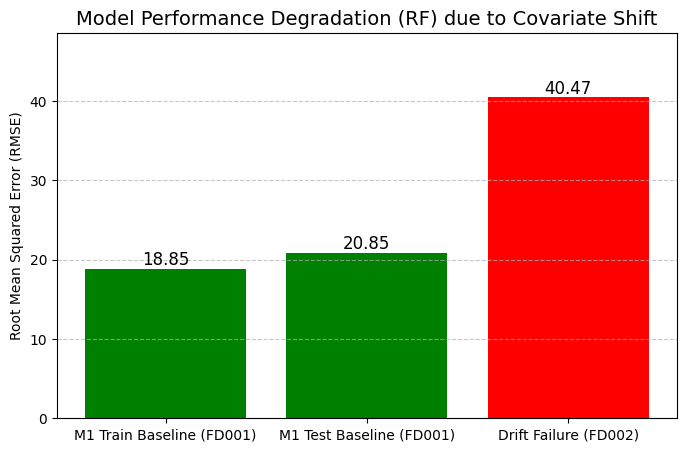

In [ ]:
plt.figure(figsize=(8, 5))
scenarios = ['M1 Train Baseline (FD001)', 'M1 Test Baseline (FD001)', 'Drift Failure (FD002)']
rmses = [18.85, test_rmse, drift_rmse]
colors = ['green', 'green', 'red']

bar_plot = plt.bar(scenarios, rmses, color=colors)
plt.bar_label(bar_plot, fmt='%.2f', fontsize=12)
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("Model Performance Degradation (RF) due to Covariate Shift", fontsize=14)
plt.ylim(0, max(rmses) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("performance_degradation.png", dpi=300, bbox_inches='tight')
plt.show()

# New Model

## Load Data from train_FD002

In [ ]:
train_2 = load_train_data('train_FD002.txt')

In [ ]:
train_2.shape

(53759, 28)

## Feature Engineering

### Operating Regime Normalization

In [ ]:
# Sensors that actually contain degradation signal
sensors = []
for col in train_2.columns:
  if train_2[col].nunique() > 1 and col.startswith('sensor'):
    sensors.append(col)
print(sensors)

['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)

normalized_cols_2, scalers = normalize_train_data(train_2, sensors, kmeans)

### Exponentially Weighted Moving Average

In [ ]:
ewma_features_2 = smooth_data(train_2, normalized_cols_2)

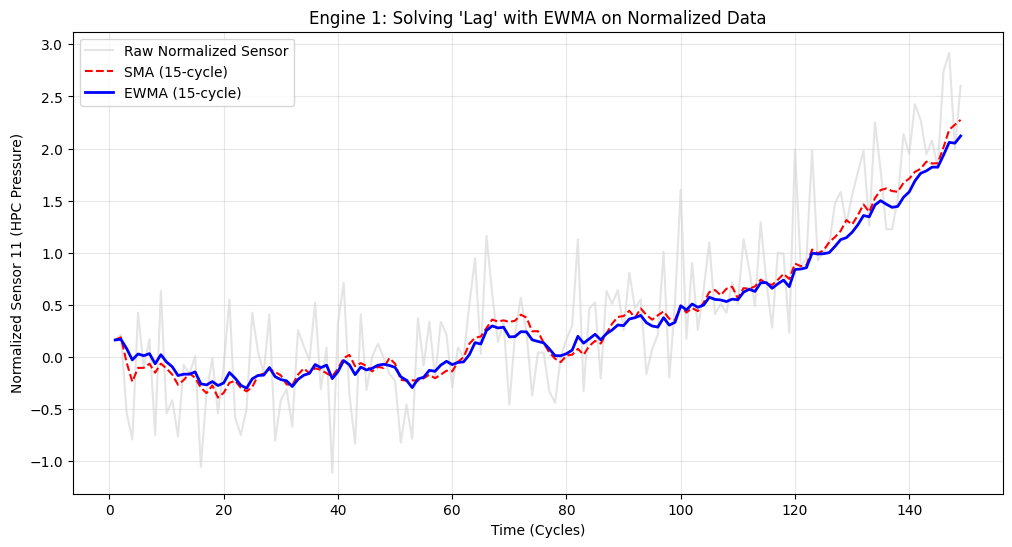

In [ ]:
engine_1 = train_2[train_2['unit'] == 1]
raw_signal = engine_1['sensor_11_norm']
sma_signal = raw_signal.rolling(10, min_periods=1).mean()
ewma_signal = engine_1['sensor_11_norm_ewma_mean']

plt.figure(figsize=(12, 6))
plt.plot(engine_1['cycle'], raw_signal, color='lightgray', label='Raw Normalized Sensor', alpha=0.6)
plt.plot(engine_1['cycle'], sma_signal, color='red', linestyle='--', label='SMA (15-cycle)')
plt.plot(engine_1['cycle'], ewma_signal, color='blue', linewidth=2, label='EWMA (15-cycle)')

plt.title("Engine 1: Solving 'Lag' with EWMA on Normalized Data")
plt.xlabel("Time (Cycles)")
plt.ylabel("Normalized Sensor 11 (HPC Pressure)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Modeling

In [ ]:
X_2 = train_2[normalized_cols_2 + ewma_features_2]
y_2 = train_2['RUL_piecewise']
groups_2 = train_2['unit']

In [ ]:
gkf = GroupKFold(n_splits=5)
xgb_rmses =[]
xgb_asy_scores =[]

In [ ]:
# Array to hold out-of-fold predictions for our final plot
train_2['xgb_preds'] = np.nan

for train_idx, val_idx in gkf.split(X_2, y_2, groups=groups_2):
  X_train, X_val = X_2.iloc[train_idx], X_2.iloc[val_idx]
  y_train, y_val = y_2.iloc[train_idx], y_2.iloc[val_idx]

  # Initialize XGBoost (Using shallow trees to prevent overfitting the noise)
  xgb_model = XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42, n_jobs=-1)

  # Train
  xgb_model.fit(X_train, y_train)

  # Predict
  preds = xgb_model.predict(X_val)

  # Evaluate
  rmse = root_mean_squared_error(y_val, preds)
  asy = asymmetric_score(y_val, preds)

  xgb_rmses.append(rmse)
  xgb_asy_scores.append(asy)

  # Save predictions
  train_2.loc[val_idx, 'xgb_preds'] = preds

In [ ]:
print(f"Cross-Validation RMSEs: {[round(val, 2) for val in xgb_rmses]}")
print(f"Cross-Validation Asymmetric Scores: {[round(val, 2) for val in xgb_asy_scores]}")

Cross-Validation RMSEs: [19.61, 16.22, 17.62, 19.54, 20.46]
Cross-Validation Asymmetric Scores: [np.float64(12.33), np.float64(7.83), np.float64(10.24), np.float64(14.61), np.float64(17.21)]


In [ ]:
print(f"Average CV RMSE: {np.mean(xgb_rmses):.2f}")
print(f"Average CV NASA Asymmetric Score: {np.mean(xgb_asy_scores):.2f}")

Average CV RMSE: 18.69
Average CV NASA Asymmetric Score: 12.44


In [ ]:
# 1. Use the cross-validation predictions already saved in DataFrame
eval_df = train_2.dropna(subset=['xgb_preds', 'RUL_piecewise']).copy()

# 2. Slice the data: Only look at engines that are actually failing (True RUL <= 30)
danger_zone_df = eval_df[eval_df['RUL_piecewise'] <= 30]

# 3. Calculate the standard RMSE on the whole dataset
overall_rmse = root_mean_squared_error(eval_df['RUL_piecewise'], eval_df['xgb_preds'])

# 4. Calculate the RMSE strictly inside the Danger Zone
danger_rmse = root_mean_squared_error(danger_zone_df['RUL_piecewise'], danger_zone_df['xgb_preds'])

print(f"Overall Lifetime RMSE: {overall_rmse:.2f} cycles")
print(f"Danger Zone RMSE (RUL <= 30): {danger_rmse:.2f} cycles")

# 5. Calculate for extreme danger (RUL <= 15)
extreme_danger_df = eval_df[eval_df['RUL_piecewise'] <= 15]
extreme_rmse = root_mean_squared_error(extreme_danger_df['RUL_piecewise'], extreme_danger_df['xgb_preds'])
print(f"Extreme Danger Zone RMSE (RUL <= 15): {extreme_rmse:.2f} cycles")

Overall Lifetime RMSE: 18.76 cycles
Danger Zone RMSE (RUL <= 30): 10.75 cycles
Extreme Danger Zone RMSE (RUL <= 15): 5.09 cycles


## Hyperparamter Tuning

In [ ]:
# 1. Get the "Full System" data from previous step
X_tune = X_2.copy()
y_tune = y_2.copy()
groups_tune = groups_2.copy()

# 2. Define the Hyperparameter Grid
param_distributions = {
    'n_estimators':[100, 200, 300],
    'max_depth':[3, 4, 5, 6],
    'learning_rate':[0.01, 0.05, 0.1],
    'subsample':[0.7, 0.8, 1.0],         # Helps prevent overfitting
    'colsample_bytree': [0.7, 0.8, 1.0]   # Helps prevent overfitting
}

# 3. Setup GroupKFold to prevent data leakage during tuning
gkf = GroupKFold(n_splits=5)

# 4. Initialize XGBoost and RandomizedSearchCV
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

asy_scorer = make_scorer(asymmetric_score, greater_is_better=False)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=15,          # Tries 15 random combinations (keeps runtime short)
    scoring=asy_scorer, # Optimizing for Asymmetric score
    cv=gkf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 5. Run the Search
random_search.fit(X_tune, y_tune, groups=groups_tune)

print(f"Best Asymmetric Score: {-random_search.best_score_:.2f}")
print("Best Hyperparameters:")
for param, value in random_search.best_params_.items():
    print(f" - {param}: {value}")

# 6. Save the Champion Model
champion_xgb_model = random_search.best_estimator_

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Asymmetric Score: 11.66
Best Hyperparameters:
 - subsample: 0.7
 - n_estimators: 300
 - max_depth: 3
 - learning_rate: 0.1
 - colsample_bytree: 0.8


In [ ]:
# Overwrite the predictions using best model
train_2['xgb_preds'] = champion_xgb_model.predict(X_tune)

danger_zone_df = train_2[train_2['RUL_piecewise'] <= 30]

# Calculate the standard RMSE and asymmetric score on the whole dataset
overall_rmse = root_mean_squared_error(train_2['RUL_piecewise'], train_2['xgb_preds'])
overall_asy = asymmetric_score(train_2['RUL_piecewise'], train_2['xgb_preds'])

# Calculate the RMSE and asymmetric score strictly inside the Danger Zone
danger_rmse = root_mean_squared_error(danger_zone_df['RUL_piecewise'], danger_zone_df['xgb_preds'])
danger_asy = asymmetric_score(danger_zone_df['RUL_piecewise'], danger_zone_df['xgb_preds'])

print(f"Overall Lifetime RMSE: {overall_rmse:.2f} cycles")
print(f"Overall NASA Asymmetric Score: {overall_asy:.2f}")
print(f"Danger Zone RMSE (RUL <= 30): {danger_rmse:.2f} cycles")
print(f"Danger Zone NASA Asymmetric Score: {danger_asy:.2f}")

# Calculate for extreme danger (RUL <= 15)
extreme_danger_df = eval_df[eval_df['RUL_piecewise'] <= 15]
extreme_rmse = root_mean_squared_error(extreme_danger_df['RUL_piecewise'], extreme_danger_df['xgb_preds'])
extreme_asy = asymmetric_score(extreme_danger_df['RUL_piecewise'], extreme_danger_df['xgb_preds'])

print(f"Extreme Danger Zone RMSE (RUL <= 15): {extreme_rmse:.2f} cycles")
print(f"Extreme Danger Zone NASA Asymmetric Score: {extreme_asy:.2f}")

Overall Lifetime RMSE: 16.70 cycles
Overall NASA Asymmetric Score: 7.90
Danger Zone RMSE (RUL <= 30): 9.67 cycles
Danger Zone NASA Asymmetric Score: 3.75
Extreme Danger Zone RMSE (RUL <= 15): 5.09 cycles
Extreme Danger Zone NASA Asymmetric Score: 0.55


## Residual Analysis

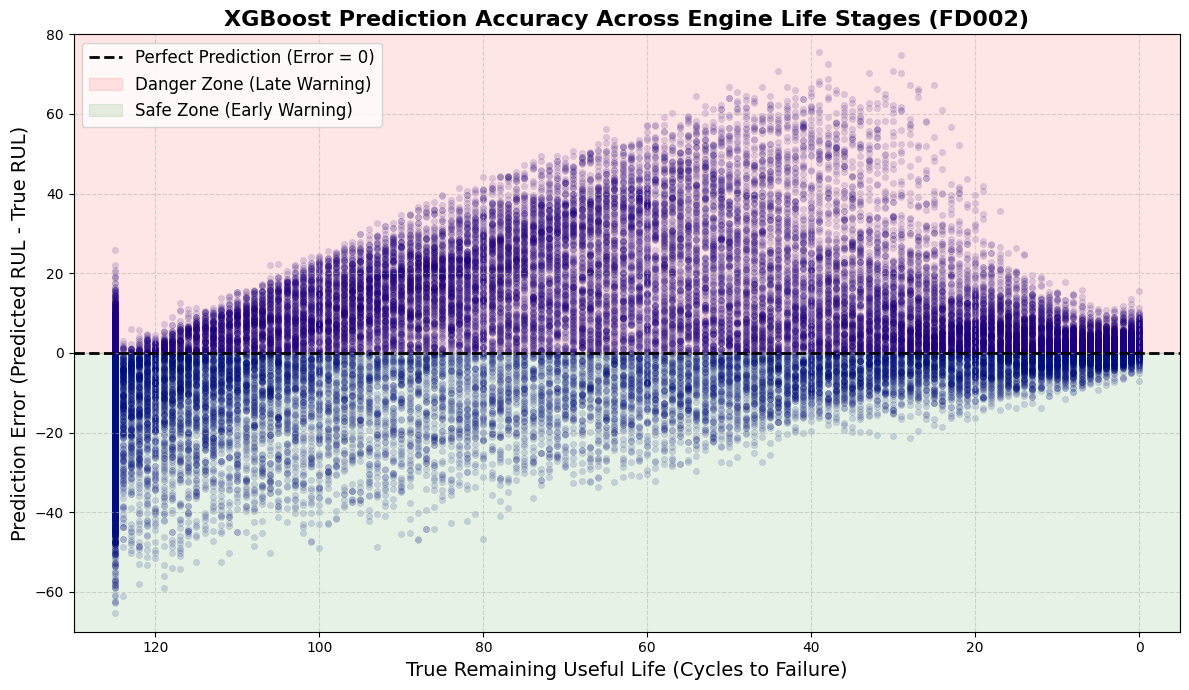

In [ ]:
# Error vs. Time plot

# 1. Calculate the prediction error
# Positive Error (+) = Model overestimated RUL (Late Warning -> DANGEROUS)
# Negative Error (-) = Model underestimated RUL (Early Warning -> SAFE)

# We use RUL_piecewise because the model was specifically trained to cap at 125
train_2['prediction_error'] = train_2['xgb_preds'] - train_2['RUL_piecewise']

# Drop NaNs just in case any cross-validation rows were missed
plot_data = train_2.dropna(subset=['xgb_preds', 'prediction_error'])

# 2. Create the Plot
plt.figure(figsize=(12, 7))

# Scatter plot of the errors
sns.scatterplot(
    x=plot_data['RUL_piecewise'],
    y=plot_data['prediction_error'],
    alpha=0.15,          # High transparency to show density
    color='darkblue',
    s=20,
    edgecolor=None
)

# 3. Add visual guides for safety
# The perfect prediction line
plt.axhline(0, color='black', linestyle='--', linewidth=2, label='Perfect Prediction (Error = 0)')

# Shade the Danger Zone (Late Warnings)
plt.axhspan(0, plot_data['prediction_error'].max() + 10, color='red', alpha=0.1, label='Danger Zone (Late Warning)')

# Shade the Safe Zone (Early Warnings)
plt.axhspan(plot_data['prediction_error'].min() - 10, 0, color='green', alpha=0.1, label='Safe Zone (Early Warning)')

# 4. Formatting
plt.title("XGBoost Prediction Accuracy Across Engine Life Stages (FD002)", fontsize=16, fontweight='bold')
plt.xlabel("True Remaining Useful Life (Cycles to Failure)", fontsize=14)
plt.ylabel("Prediction Error (Predicted RUL - True RUL)", fontsize=14)

# FLIP THE X-AXIS! This makes time move from left to right (125 down to 0)
plt.gca().invert_xaxis()

# Set limits to make the plot clean
plt.xlim(130, -5)
plt.ylim(-70, 80)

plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("error_time_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## Explainability (XAI)

In [ ]:
SENSOR_DICT = {
    'sensor_1': 'Fan Inlet Temp',
    'sensor_2': 'LPC Outlet Temp',
    'sensor_3': 'HPC Outlet Temp',
    'sensor_4': 'LPT Outlet Temp',
    'sensor_5': 'Fan Inlet Pressure',
    'sensor_6': 'Bypass-duct Pressure',
    'sensor_7': 'HPC Outlet Pressure',
    'sensor_8': 'Physical Fan Speed',
    'sensor_9': 'Physical Core Speed',
    'sensor_10': 'Engine pressure ratio',
    'sensor_11': 'HPC Static Pressure',
    'sensor_12': 'Fuel Flow Ratio',
    'sensor_13': 'Corrected Fan Speed',
    'sensor_14': 'Corrected Core Speed',
    'sensor_15': 'Bypass Ratio',
    'sensor_16': 'Burner Fuel-air ratio',
    'sensor_17': 'Bleed Enthalpy',
    'sensor_18': 'Demanded Fan Speed',
    'sensor_19': 'Demanded Corrected Fan Speed',
    'sensor_20': 'HPT Coolant Bleed',
    'sensor_21': 'LPT Coolant Bleed'
}

In [ ]:
# 1. Create a dictionary to map feature names to plain English
# Create mappings for ewma features
feature_name_map = {}
for sensor_id, name in SENSOR_DICT.items():
    # Mapping for the normalized sensor itself (if you included them)
    feature_name_map[f'{sensor_id}_norm'] = f"{name} (Instantaneous)"
    # Mapping for the EWMA mean
    feature_name_map[f'{sensor_id}_norm_ewma_mean'] = f"{name} (Trend)"
    # Mapping for the EWMA standard deviation
    feature_name_map[f'{sensor_id}_norm_ewma_std'] = f"{name} (Volatility)"

# 2. Get feature importances from the trained champion model
importances = pd.DataFrame({
    'feature': champion_xgb_model.feature_names_in_,
    'importance': champion_xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# 3. Translate the feature names using our dictionary
importances['feature_name'] = importances['feature'].map(feature_name_map)

importances.head()

,feature,importance,feature_name
41,sensor_11_norm_ewma_mean,0.338376,HPC Static Pressure (Trend)
27,sensor_4_norm_ewma_mean,0.131434,LPT Outlet Temp (Trend)
49,sensor_15_norm_ewma_mean,0.094222,Bypass Ratio (Trend)
35,sensor_8_norm_ewma_mean,0.055866,Physical Fan Speed (Trend)
45,sensor_13_norm_ewma_mean,0.052833,Corrected Fan Speed (Trend)


/tmp/ipykernel_6991/2440556412.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




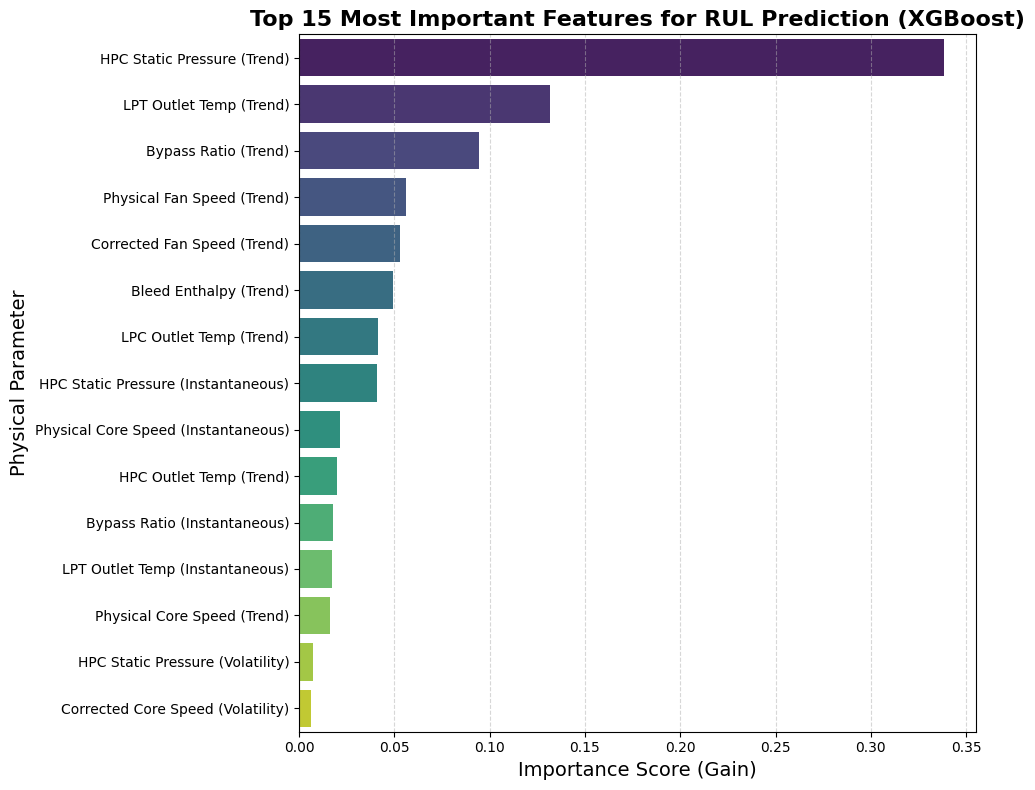

In [ ]:
# 4. Create the plot
plt.figure(figsize=(10, 8))
sns.barplot(
    x='importance',
    y='feature_name',
    data=importances.head(15), # Plot only the top 15 features
    palette='viridis'
)

plt.title('Top 15 Most Important Features for RUL Prediction (XGBoost)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score (Gain)', fontsize=14)
plt.ylabel('Physical Parameter', fontsize=14)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

## Evaluation

In [ ]:
test_2_copy = test_2.copy()

In [ ]:
# A. Regime Normalization
test_normalized_cols_2 = normalize_test_data(test_2_copy, sensors, kmeans, scalers)

# B. EWMA Smoothing
test_ewma_features_2 = smooth_data(test_2_copy, test_normalized_cols_2)

# C. Get the final data point for each engine
X_test_2_copy = test_2_copy.groupby('unit').tail(15)[test_normalized_cols_2 + test_ewma_features_2]

In [ ]:
final_preds_2 = champion_xgb_model.predict(X_test_2_copy)
final_rmse_2 = root_mean_squared_error(y_true_drift, final_preds_2)
final_asy_2 = asymmetric_score(y_true_drift.values, final_preds_2)

In [ ]:
print(f"Final RMSE: {final_rmse_2:.2f}")
print(f"Final NASA Asymmetric Score: {final_asy_2:.2f}")

Final RMSE: 17.42
Final NASA Asymmetric Score: 8.16


In [ ]:
# Overall RMSE and Asymmetric Score
X_test_all = test_2_copy[test_normalized_cols_2 + test_ewma_features_2]
y_test_all = test_2_copy['True_RUL_piecewise']
overall_preds = champion_xgb_model.predict(X_test_all)
overall_rmse = root_mean_squared_error(y_test_all, overall_preds)
overall_asy = asymmetric_score(y_test_all, overall_preds)

print(f"Overall RMSE (On complex FD002 data): {overall_rmse:.2f}")
print(f"Overall Asymmetric Score (On complex FD002 data): {overall_asy:.2f}")

Overall RMSE (On complex FD002 data): 18.09
Overall Asymmetric Score (On complex FD002 data): 8.50


In [ ]:
# Filter for the "Danger Zone" (e.g., True RUL <= 30)
danger_zone_test = test_2_copy[test_2_copy['True_RUL_piecewise'] <= 30]

# Make predictions on just these highly degraded rows
X_danger_test = danger_zone_test[test_normalized_cols_2 + test_ewma_features_2]
danger_preds = champion_xgb_model.predict(X_danger_test)
y_danger_test = danger_zone_test['True_RUL_piecewise']

# Calculate the RMSE
danger_test_rmse = root_mean_squared_error(y_danger_test, danger_preds)
danger_test_asy = asymmetric_score(y_danger_test, danger_preds)

print(f"Danger Zone RMSE (On complex FD002 data): {danger_test_rmse:.2f}")
print(f"Danger Zone Asymmetric Score (On complex FD002 data): {danger_test_asy:.2f}")

Danger Zone RMSE (On complex FD002 data): 15.14
Danger Zone Asymmetric Score (On complex FD002 data): 22.74


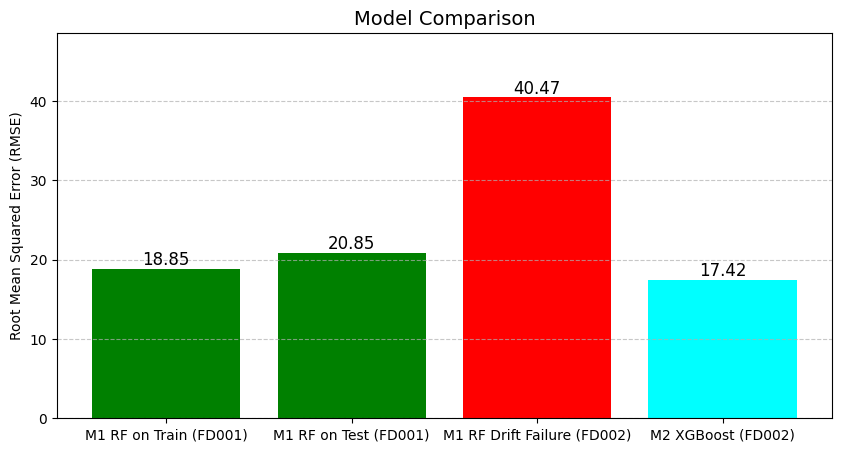

In [ ]:
plt.figure(figsize=(10, 5))
scenarios = ['M1 RF on Train (FD001)', 'M1 RF on Test (FD001)', 'M1 RF Drift Failure (FD002)', 'M2 XGBoost (FD002)']
rmses = [18.85, test_rmse, drift_rmse, final_rmse_2]
colors = ['green', 'green', 'red', 'aqua']

bar_plot = plt.bar(scenarios, rmses, color=colors)
plt.bar_label(bar_plot, fmt='%.2f', fontsize=12)
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("Model Comparison", fontsize=14)
plt.ylim(0, max(rmses) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("performance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Unsupervised Anomaly Monitor

In [ ]:
# 1. We use the 'X_tune' data from previous step (Norm + EWMA features)
# Even though we normalized by regime, we do one final global scale so PCA treats all EWMA features equally.
pca_scaler = StandardScaler()
X_pca_ready = pca_scaler.fit_transform(X_tune)

# 2. Fit PCA (Reduce down to 2 dimensions for the Streamlit UI)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_pca_ready)

train_2['PC1'] = X_pca[:, 0]
train_2['PC2'] = X_pca[:, 1]

print(f"Variance explained by 2 Components: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

# 3. Define the "Healthy" baseline. We use data where RUL is capped at 125.
healthy_mask = train_2['RUL_piecewise'] == 125
healthy_pca_data = train_2[healthy_mask][['PC1', 'PC2']]

Variance explained by 2 Components: 43.84%


In [ ]:
pca_ml = PCA(random_state=42)
pca_ml.fit(X_pca_ready)
cum_variance = pca_ml.explained_variance_ratio_.cumsum()
thresholds = np.arange(.5,1,.05)
n_pcs = []
for threshold in thresholds:
  for i in range(len(cum_variance)):
    if cum_variance[i] >= threshold:
      n_pcs.append(i+1)
      break
print(pd.DataFrame({'Threshold': thresholds, 'Number of PCs': n_pcs}))

   Threshold  Number of PCs
0       0.50              4
1       0.55              5
2       0.60              7
3       0.65              9
4       0.70             13
5       0.75             16
6       0.80             20
7       0.85             24
8       0.90             28
9       0.95             35


In [ ]:
# A quick loop to test if 1, 2, 3, or 4 clusters is best for the Healthy data
n_components_range = range(1, 30)
bic_scores =[]

for n in n_components_range:
    test_gmm = GaussianMixture(n_components=n, random_state=42)
    test_gmm.fit(healthy_pca_data)
    bic_scores.append(test_gmm.bic(healthy_pca_data))

# The lowest BIC score represents the optimal number of clusters
optimal_n = n_components_range[np.argmin(bic_scores)]
print(f"Optimal number of GMM components according to BIC: {optimal_n}")

Optimal number of GMM components according to BIC: 9


In [ ]:
# 4. Train the Gaussian Mixture Model ONLY on the healthy cluster
gmm = GaussianMixture(n_components=9, covariance_type='full', random_state=42)
gmm.fit(healthy_pca_data)

print("Step 3: Scoring all data to generate the Confidence Metric...")
# 5. Score every single data point.
# .score_samples() returns the log-likelihood. (Highly negative numbers = Anomaly/Drift)
log_probs = gmm.score_samples(train_2[['PC1', 'PC2']])

# 6. Use Min-Max Scaling for a much smoother dashboard gauge
# We use the 1st and 99th percentiles so extreme outliers don't break the math
lower_bound = np.percentile(log_probs, 1)  # The "Danger" threshold
upper_bound = np.percentile(log_probs, 99) # The "Perfect Health" threshold

# linearly interpolate the log_probs to a 1 to 100 scale
smooth_scores = np.interp(log_probs, (lower_bound, upper_bound), (1, 100))

# Overwrite the old column with the new, smooth scores
train_2['Confidence_Score'] = smooth_scores

Step 3: Scoring all data to generate the Confidence Metric...


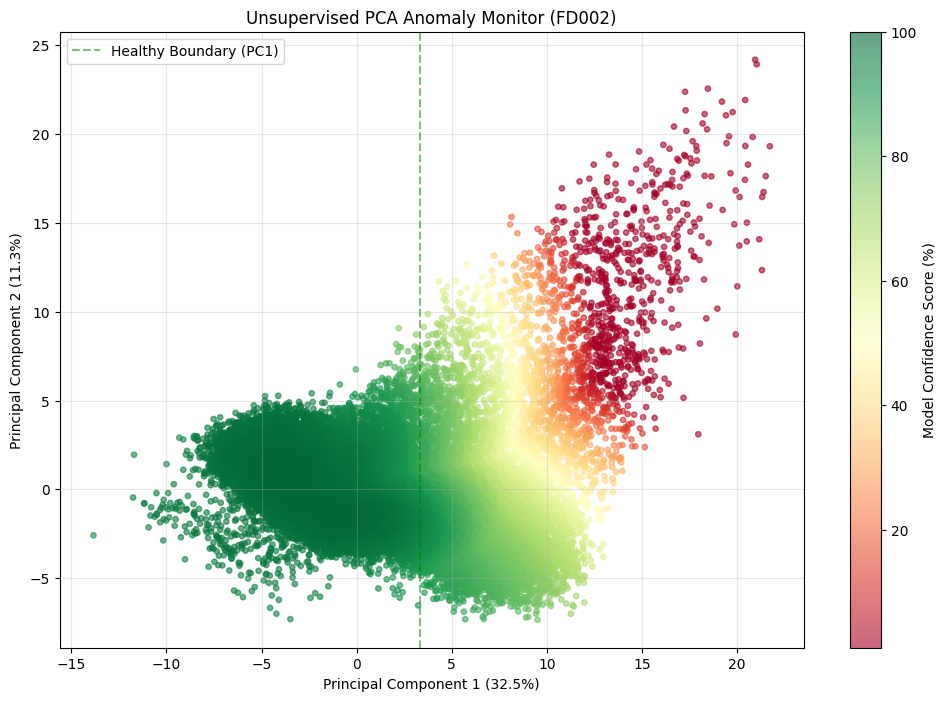

In [ ]:
# VISUALIZATION: THE ANOMALY MONITOR DASHBOARD PROTOTYPE

plt.figure(figsize=(12, 8))

# Scatter plot colored by the new Confidence Score
# RdYlGn (Red-Yellow-Green) colormap perfectly mimics a safety dashboard
scatter = plt.scatter(train_2['PC1'], train_2['PC2'],
                      c=train_2['Confidence_Score'],
                      cmap='RdYlGn', alpha=0.6, s=15)

plt.colorbar(scatter, label='Model Confidence Score (%)')

# Draw a rough boundary to represent the GMM "Safe Zone" (For visual purposes)
plt.axvline(x=healthy_pca_data['PC1'].max(), color='green', linestyle='--', alpha=0.5, label='Healthy Boundary (PC1)')

plt.title("Unsupervised PCA Anomaly Monitor (FD002)")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("anomaly_monitor.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# EXPERIMENT 1: TRAIN XGBOOST ON ONLY THE 2 PCA COMPONENTS

# We use the PCA data already generated
X_pca_only = train_2[['PC1', 'PC2']]
y_pca = train_2['RUL_piecewise']
groups_pca = train_2['unit']

gkf = GroupKFold(n_splits=5)
pca_rmses, pca_asy_scores = [], []

for train_idx, val_idx in gkf.split(X_pca_only, y_pca, groups=groups_pca):
    X_train, X_val = X_pca_only.iloc[train_idx], X_pca_only.iloc[val_idx]
    y_train, y_val = y_pca.iloc[train_idx], y_pca.iloc[val_idx]

    # Use your champion hyperparameters
    model = XGBRegressor(subsample=0.7, n_estimators=300, max_depth=3, learning_rate=0.1, colsample_bytree=0.8, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    pca_rmses.append(root_mean_squared_error(y_val, preds))
    pca_asy_scores.append(asymmetric_score(y_val, preds))

pca_avg_rmse = np.mean(pca_rmses)
pca_total_asy = np.sum(pca_asy_scores)

# EXPERIMENT 2: RE-RUN XGBOOST ON THE FULL FEATURE SET

# Previous best score was 18.65, we will use that for comparison
full_feature_avg_rmse = 18.53

# Display the results
print(f"RMSE using ALL 28 Features:        {full_feature_avg_rmse:.2f}")
print(f"RMSE using ONLY 2 PCA Components:  {pca_avg_rmse:.2f}")

performance_loss = ((pca_avg_rmse - full_feature_avg_rmse) / full_feature_avg_rmse) * 100
print(f"\nPerformance Loss from Dimensionality Reduction: {performance_loss:.2f}%")

RMSE using ALL 28 Features:        18.53
RMSE using ONLY 2 PCA Components:  19.41

Performance Loss from Dimensionality Reduction: 4.74%


# Data Drift Detector

In [ ]:
# LOAD FD004 DATA
test_4 = load_test_data('test_FD004.txt', 'RUL_FD004.txt')

# We will just look at Engine 1 from FD004 for this visual proof
engine_4 = test_4[test_4['unit'] == 1].copy()

# Normalization using FD002's Scaler logic
normalized_cols_4 = normalize_test_data(engine_4, sensors, kmeans, scalers)

# EWMA Smoothing
ewma_features_4 = smooth_data(engine_4, normalized_cols_4)

In [ ]:
# Apply FD002's PCA
X_pca_ready_4 = pca_scaler.transform(engine_4[normalized_cols_4 + ewma_features_4])
pca_coords_4 = pca.transform(X_pca_ready_4)

engine_4['PC1'] = pca_coords_4[:, 0]
engine_4['PC2'] = pca_coords_4[:, 1]

# Score with FD002's GMM
log_probs_4 = gmm.score_samples(engine_4[['PC1', 'PC2']])

lower_bound_4 = np.percentile(log_probs_4, 1)  # The "Danger" threshold
upper_bound_4 = np.percentile(log_probs_4, 99) # The "Perfect Health" threshold

# linearly interpolate the log_probs to a 1 to 100 scale
smooth_scores = np.interp(log_probs_4, (lower_bound_4, upper_bound_4), (1, 100))

engine_4['Confidence_Score'] = smooth_scores

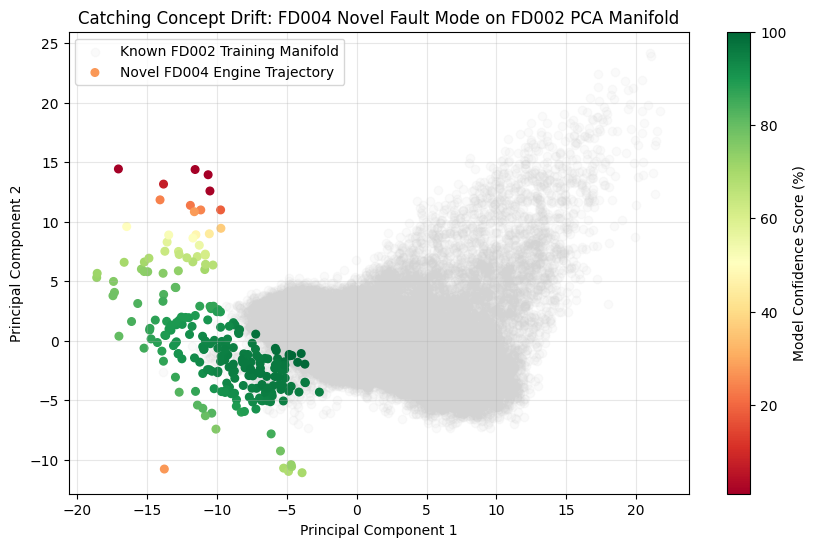

In [ ]:
plt.figure(figsize=(10, 6))

# Plot the original FD002 "Known" Manifold in light grey as a background
plt.scatter(train_2['PC1'], train_2['PC2'], color='lightgray', alpha=0.1, label='Known FD002 Training Manifold')

# Plot the new FD004 Engine trajectory
scatter = plt.scatter(engine_4['PC1'], engine_4['PC2'],
                      c=engine_4['Confidence_Score'], cmap='RdYlGn', s=30, label='Novel FD004 Engine Trajectory')

plt.colorbar(scatter, label='Model Confidence Score (%)')
plt.title("Catching Concept Drift: FD004 Novel Fault Mode on FD002 PCA Manifold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("drift_detector.png", dpi=300, bbox_inches='tight')
plt.show()

# Test Model Performance on test_FD001

In [ ]:
# 1. LOAD THE DATA
train_1 = load_train_data('train_FD001.txt')
test_1 = load_test_data('test_FD001.txt', 'RUL_FD001.txt')

# Target for training and testing
y_train = train_1['RUL_piecewise']
y_test_true = test_1.groupby('unit').tail(15)['True_RUL_piecewise']

# 2. APPLY OUR CHAMPION ARCHITECTURE (EWMA)
sensors = []
for col in train_1.columns:
  if train_1[col].nunique() > 1 and col.startswith('sensor'):
    sensors.append(col)

window_span = 15
ewma_features =[]

# Apply to Train
for col in sensors:
  train_1[f'{col}_ewma_mean'] = train_1.groupby('unit')[col].transform(lambda x: x.ewm(span=window_span, adjust=False).mean())
  train_1[f'{col}_ewma_std'] = train_1.groupby('unit')[col].transform(lambda x: x.ewm(span=window_span, adjust=False).std().fillna(0))
  if f'{col}_ewma_mean' not in ewma_features:
      ewma_features.extend([f'{col}_ewma_mean', f'{col}_ewma_std'])

# Apply to Test
for col in sensors:
  test_1[f'{col}_ewma_mean'] = test_1.groupby('unit')[col].transform(lambda x: x.ewm(span=window_span, adjust=False).mean())
  test_1[f'{col}_ewma_std'] = test_1.groupby('unit')[col].transform(lambda x: x.ewm(span=window_span, adjust=False).std().fillna(0))

X_train = train_1[sensors + ewma_features]
# For the test set, we only predict on the VERY LAST cycle of each engine
X_test = test_1.groupby('unit').tail(15)[sensors + ewma_features]


# 3. TRAIN AND EVALUATE ON THE BLIND HOLDOUT
# Use the optimal hyperparameters we found earlier
ols_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
best_xgb_model = XGBRegressor(subsample=0.7, n_estimators=300, max_depth=3, learning_rate=0.1, colsample_bytree=0.8, random_state=42, n_jobs=-1)

models = [("OLS", ols_model), ("Random Forest", rf_model), ("XGBoost", best_xgb_model)]

for name, model in models:
  model.fit(X_train, y_train)
  final_predictions = model.predict(X_test)

  final_rmse = root_mean_squared_error(y_test_true, final_predictions)

  final_asy = asymmetric_score(y_test_true.values, final_predictions)

  print(f"{name} Training RMSE: {root_mean_squared_error(y_train, model.predict(X_train)):.2f}")
  print(f"{name} Training NASA Asymmetric Score: {asymmetric_score(y_train.values, model.predict(X_train)):.2f}")
  print(f"{name} Final RMSE: {final_rmse:.2f}")
  print(f"{name} Final NASA Asymmetric Score: {final_asy:.2f}")

OLS Training RMSE: 20.11
OLS Training NASA Asymmetric Score: 10.00
OLS Final RMSE: 20.79
OLS Final NASA Asymmetric Score: 12.46
Random Forest Training RMSE: 10.23
Random Forest Training NASA Asymmetric Score: 2.23
Random Forest Final RMSE: 18.86
Random Forest Final NASA Asymmetric Score: 9.54
XGBoost Training RMSE: 12.29
XGBoost Training NASA Asymmetric Score: 2.73
XGBoost Final RMSE: 16.71
XGBoost Final NASA Asymmetric Score: 6.11


# Export Model

In [ ]:
import joblib
import os

# Create a folder to hold exported models
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

print("Exporting models for Streamlit...")

# 1. The Clustering Model & Scaler for Regime Normalization
joblib.dump(kmeans, 'models/kmeans_regime_classifier.joblib')
joblib.dump(scalers, 'models/regime_scalers_dict.joblib') # Note: You'll need to adapt how you apply this in Streamlit, or save a scaler per regime

# 2. The Supervised Champion Model
joblib.dump(champion_xgb_model, 'models/champion_xgb_model.joblib')

# 3. The Unsupervised Drift Monitor
joblib.dump(pca_scaler, 'models/pca_scaler.joblib')
joblib.dump(pca, 'models/pca_transformer.joblib')
joblib.dump(gmm, 'models/gmm_anomaly_detector.joblib')
joblib.dump((lower_bound, upper_bound), 'models/confidence_bounds.joblib')

# Let's also save a clean sample of the test data so the Streamlit app has something to stream!
# We will save Engine 11 from the test_FD002 set (it has a nice long life to simulate)
sample_engine = train_2[train_2['unit'] == 11].copy()
sample_engine['Predicted_RUL'] = champion_xgb_model.predict(sample_engine[normalized_cols_2 + ewma_features_2])
sample_engine.to_csv('data/train2_sample_engine.csv', index=False)

engine_4[engine_4['unit'] == 1].to_csv('data/test4_sample_engine.csv', index=False)

print("All artifacts successfully exported to the '/models' folder!")

Exporting models for Streamlit...
All artifacts successfully exported to the '/models' folder!
